# Multi-Pair Results: MNIST and Fashion-MNIST

This notebook runs a fixed-hyperparameter diagnostic benchmark across multiple binary pairs.

Purpose for the meeting:

- compare Raw SVM, Separate Dictionary + SVM, and Joint Dictionary + SVM across several pairs;
- inspect whether the joint method behaves consistently across task difficulty;
- visualize accuracy, overfitting gap, margin violation, reconstruction, and sparsity;
- avoid per-pair hyperparameter tuning for now, so the comparison remains simple and fast to explain.

Important: these are not final tuned results. They are diagnostic results under one fixed configuration.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import math
import numpy as np
import matplotlib.pyplot as plt

from src.config import default_hyperparams, mnist_task_suite, fashion_task_suite
from src.experiments import (
    run_task_suite,
    flatten_comparison_rows,
    summarize_method_aggregate,
    format_method_aggregate_summary,
)


## Fixed Hyperparameters

For this diagnostic benchmark, all pairs use the same hyperparameters.

The baseline and joint models share representation/classifier controls where possible:

- `dictionary_size`, `mu`, `gamma`, `max_iter`, and solver settings are common;
- `rho`, `eta`, and initialization scales are joint-specific;
- no validation-based tuning is performed in this notebook.


In [ ]:
baseline_hyper = default_hyperparams()
joint_hyper = default_hyperparams()

# Shared controls for dictionary capacity, sparsity, classifier regularization, and budget.
for hyper in (baseline_hyper, joint_hyper):
    hyper.dictionary_size = 48
    hyper.mu = 0.5
    hyper.gamma = 10
    hyper.max_iter = 100
    hyper.random_state = 42

# Joint-only controls.
joint_hyper.rho = 10
joint_hyper.eta = 10
joint_hyper.init_code_scale = 5e-3
joint_hyper.init_classifier_scale = 5e-3

print('baseline_hyper:', baseline_hyper)
print('joint_hyper:', joint_hyper)


baseline_hyper: HyperParams(dictionary_size=48, mu=0.5, rho=1.0, gamma=20, eta=1.0, init_code_scale=0.001, init_classifier_scale=0.001, initial_step=1.0, backtracking_shrink=0.5, backtracking_min_step=1e-08, max_iter=100, tol=1e-05, random_state=42)
joint_hyper: HyperParams(dictionary_size=48, mu=0.5, rho=10, gamma=20, eta=10, init_code_scale=0.005, init_classifier_scale=0.005, initial_step=1.0, backtracking_shrink=0.5, backtracking_min_step=1e-08, max_iter=100, tol=1e-05, random_state=42)


## Task Suite

The suite includes four MNIST digit pairs and four Fashion-MNIST pairs.

The goal is not to cherry-pick a single favorable pair, but to observe whether the joint method is stable across easier and harder binary tasks.

In [3]:
tasks = list(mnist_task_suite()) + list(fashion_task_suite())

for task in tasks:
    print(f'{task.dataset:13s} | {task.name:20s} | {task.label_description()}')


mnist         | 3 vs 8               | 3 vs 8
mnist         | 4 vs 9               | 4 vs 9
mnist         | 1 vs 7               | 1 vs 7
mnist         | 5 vs 8               | 5 vs 8
fashion_mnist | T-shirt vs Shirt     | 0 vs 6
fashion_mnist | Pullover vs Coat     | 2 vs 4
fashion_mnist | Dress vs Coat        | 3 vs 4
fashion_mnist | Sandal vs Sneaker    | 5 vs 7


## Run Benchmark

This cell runs all methods on all pairs. It may take a while because each pair trains Raw SVM, Separate Dictionary + SVM, and Joint Dictionary + SVM.

In [32]:
task_results = run_task_suite(tasks, baseline_hyper, joint_hyper)
comparison_rows = flatten_comparison_rows(task_results)

task_meta = {result['task']['name']: result['task'] for result in task_results}
for row in comparison_rows:
    meta = task_meta[row['task']]
    row['dataset'] = meta['dataset']
    row['pair'] = meta['name']
    row['train_test_gap'] = row['train_accuracy'] - row['test_accuracy']

print(f'completed tasks: {len(task_results)}')
print(f'comparison rows: {len(comparison_rows)}')


completed tasks: 8
comparison rows: 24


## Table Helpers

In [33]:
def _format_value(value, digits=4):
    if value is None:
        return ''
    if isinstance(value, float):
        if not math.isfinite(value):
            return ''
        return f'{value:.{digits}g}'
    return str(value)


def print_table(rows, columns, digits=4, max_rows=None):
    selected = rows if max_rows is None else rows[:max_rows]
    print(' | '.join(columns))
    print(' | '.join(['---'] * len(columns)))
    for row in selected:
        print(' | '.join(_format_value(row.get(col), digits=digits) for col in columns))


def aggregate_by_dataset_method(rows):
    grouped = {}
    for row in rows:
        key = (row['dataset'], row['method'])
        grouped.setdefault(key, []).append(row)

    output = []
    metrics = [
        'test_accuracy',
        'train_test_gap',
        'test_score_gap',
        'test_violation_rate',
        'test_reconstruction_error',
        'test_code_sparsity_1em3',
    ]
    for (dataset, method), members in sorted(grouped.items()):
        summary = {'dataset': dataset, 'method': method, 'tasks': len(members)}
        for metric in metrics:
            values = np.array([member.get(metric, np.nan) for member in members], dtype=np.float64)
            finite = values[np.isfinite(values)]
            summary[f'{metric}_mean'] = float(finite.mean()) if finite.size else float('nan')
            summary[f'{metric}_std'] = float(finite.std()) if finite.size else float('nan')
        output.append(summary)
    return output


## Task-Level Results

In [34]:
task_columns = [
    'dataset',
    'pair',
    'method',
    'train_accuracy',
    'val_accuracy',
    'test_accuracy',
    'train_test_gap',
    'test_score_gap',
    'test_violation_rate',
    'test_reconstruction_error',
    'test_code_sparsity_1em3',
]

print_table(comparison_rows, task_columns, digits=4)


dataset | pair | method | train_accuracy | val_accuracy | test_accuracy | train_test_gap | test_score_gap | test_violation_rate | test_reconstruction_error | test_code_sparsity_1em3
--- | --- | --- | --- | --- | --- | --- | --- | --- | --- | ---
mnist | 3 vs 8 | Raw SVM | 0.991 | 0.975 | 0.96 | 0.031 | 3.098 | 0.2425 |  | 
mnist | 3 vs 8 | Separate Dict + SVM | 0.958 | 0.96 | 0.945 | 0.013 | 1.12 | 0.935 | 73.89 | 0.1496
mnist | 3 vs 8 | Joint Dict + SVM | 1 | 0.965 | 0.9425 | 0.0575 | 1.524 | 0.715 | 82.7 | 0.1754
mnist | 4 vs 9 | Raw SVM | 0.986 | 0.96 | 0.935 | 0.051 | 2.718 | 0.3325 |  | 
mnist | 4 vs 9 | Separate Dict + SVM | 0.951 | 0.94 | 0.9325 | 0.0185 | 1.031 | 0.9425 | 57.58 | 0.1761
mnist | 4 vs 9 | Joint Dict + SVM | 1 | 0.955 | 0.935 | 0.065 | 1.38 | 0.7775 | 71.42 | 0.2321
mnist | 1 vs 7 | Raw SVM | 1 | 0.995 | 0.995 | 0.005 | 3.715 | 0.09 |  | 
mnist | 1 vs 7 | Separate Dict + SVM | 0.982 | 0.975 | 0.9825 | -0.0005 | 1.255 | 0.9775 | 56.84 | 0.3872
mnist | 1 vs 7 | Join

## Aggregate Results by Dataset and Method

In [35]:
aggregate_rows = aggregate_by_dataset_method(comparison_rows)
aggregate_columns = [
    'dataset',
    'method',
    'tasks',
    'test_accuracy_mean',
    'test_accuracy_std',
    'train_test_gap_mean',
    'test_score_gap_mean',
    'test_violation_rate_mean',
    'test_reconstruction_error_mean',
    'test_code_sparsity_1em3_mean',
]

print_table(aggregate_rows, aggregate_columns, digits=4)


dataset | method | tasks | test_accuracy_mean | test_accuracy_std | train_test_gap_mean | test_score_gap_mean | test_violation_rate_mean | test_reconstruction_error_mean | test_code_sparsity_1em3_mean
--- | --- | --- | --- | --- | --- | --- | --- | --- | ---
fashion_mnist | Joint Dict + SVM | 4 | 0.8881 | 0.04998 | 0.1119 | 1.283 | 0.7531 | 68.45 | 0.241
fashion_mnist | Raw SVM | 4 | 0.895 | 0.05736 | 0.06925 | 2.375 | 0.4481 |  | 
fashion_mnist | Separate Dict + SVM | 4 | 0.8869 | 0.0529 | -0.000375 | 0.8111 | 0.9837 | 65.09 | 0.2211
mnist | Joint Dict + SVM | 4 | 0.9469 | 0.01806 | 0.05312 | 1.477 | 0.7431 | 75.37 | 0.2471
mnist | Raw SVM | 4 | 0.9587 | 0.02274 | 0.0325 | 3.046 | 0.25 |  | 
mnist | Separate Dict + SVM | 4 | 0.9494 | 0.01964 | 0.01187 | 1.102 | 0.9544 | 64.76 | 0.2152


## Plot Helpers

In [36]:
METHOD_ORDER = ['Raw SVM', 'Separate Dict + SVM', 'Joint Dict + SVM']
COLORS = {
    'Raw SVM': '#4c78a8',
    'Separate Dict + SVM': '#f58518',
    'Joint Dict + SVM': '#54a24b',
}


def _task_label(row):
    prefix = 'MNIST' if row['dataset'] == 'mnist' else 'Fashion'
    return f'{prefix}: {row["pair"]}'


def plot_metric_by_task(rows, metric, title, ylabel):
    labels = []
    for row in rows:
        label = _task_label(row)
        if label not in labels:
            labels.append(label)

    x = np.arange(len(labels), dtype=np.float64)
    width = 0.24
    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.2), 4.8))

    for idx, method in enumerate(METHOD_ORDER):
        values = []
        for label in labels:
            match = next((row for row in rows if _task_label(row) == label and row['method'] == method), None)
            value = float('nan') if match is None else float(match.get(metric, float('nan')))
            values.append(value)
        ax.bar(x + (idx - 1) * width, values, width=width, label=method, color=COLORS[method])

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(axis='y', alpha=0.25)
    ax.legend()
    fig.tight_layout()
    return fig, ax


def plot_tradeoff(rows, x_metric, y_metric, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(7, 5))
    for method in METHOD_ORDER:
        method_rows = [row for row in rows if row['method'] == method]
        xs = np.array([row.get(x_metric, np.nan) for row in method_rows], dtype=np.float64)
        ys = np.array([row.get(y_metric, np.nan) for row in method_rows], dtype=np.float64)
        mask = np.isfinite(xs) & np.isfinite(ys)
        if np.any(mask):
            ax.scatter(xs[mask], ys[mask], label=method, color=COLORS[method], s=55, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    return fig, ax


## Visualizations

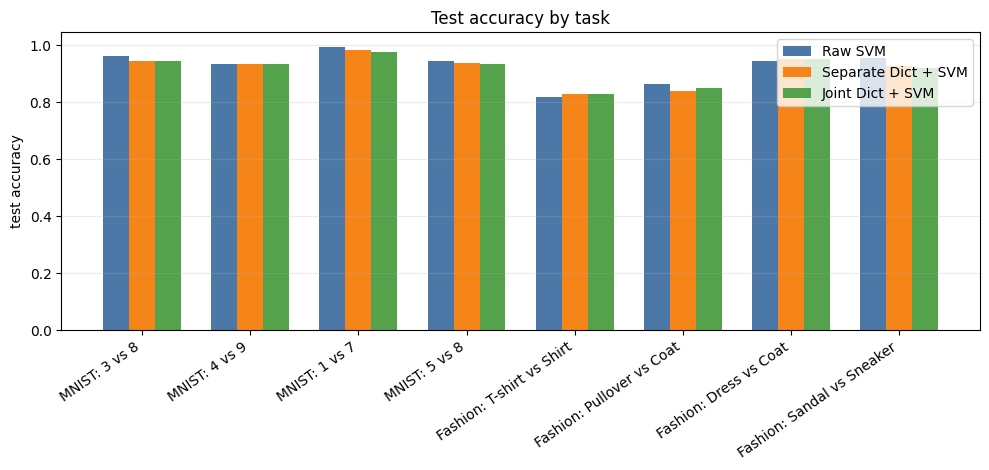

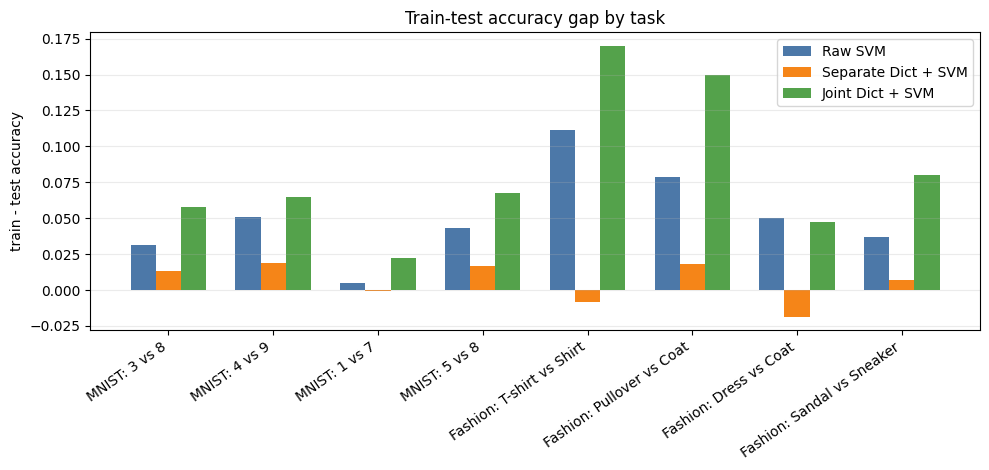

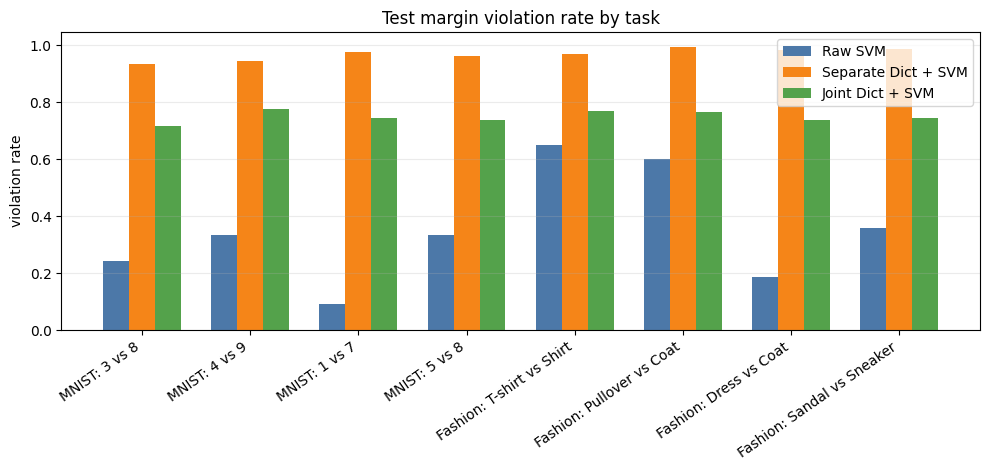

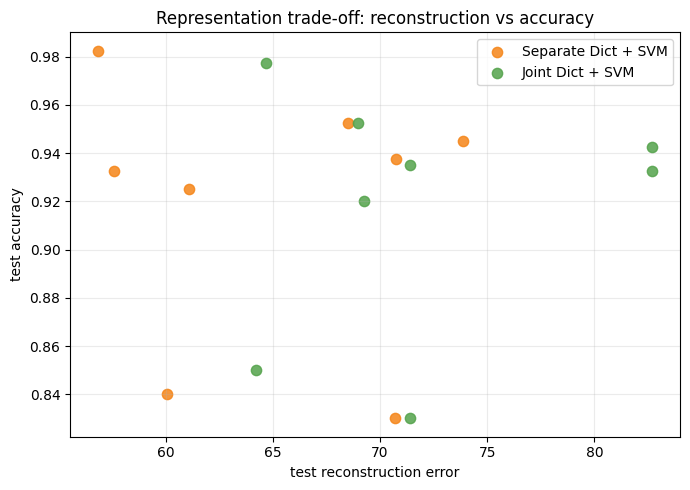

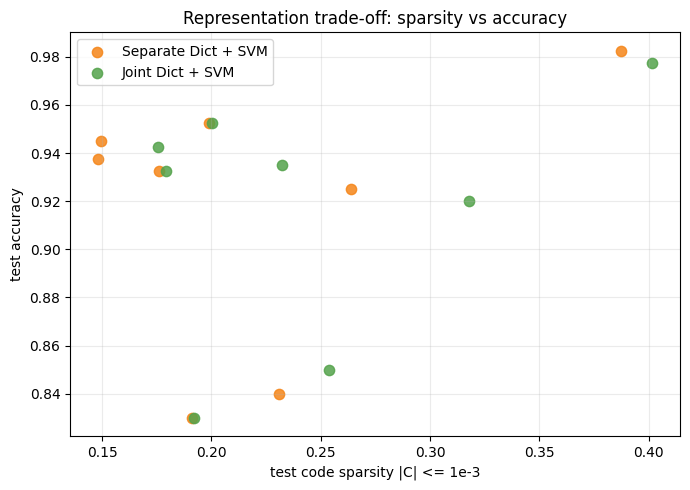

In [37]:
plot_metric_by_task(comparison_rows, 'test_accuracy', 'Test accuracy by task', 'test accuracy')
plot_metric_by_task(comparison_rows, 'train_test_gap', 'Train-test accuracy gap by task', 'train - test accuracy')
plot_metric_by_task(comparison_rows, 'test_violation_rate', 'Test margin violation rate by task', 'violation rate')
plot_tradeoff(
    comparison_rows,
    'test_reconstruction_error',
    'test_accuracy',
    'Representation trade-off: reconstruction vs accuracy',
    'test reconstruction error',
    'test accuracy',
)
plot_tradeoff(
    comparison_rows,
    'test_code_sparsity_1em3',
    'test_accuracy',
    'Representation trade-off: sparsity vs accuracy',
    'test code sparsity |C| <= 1e-3',
    'test accuracy',
)
plt.show()


## Meeting Notes Template

Use the cells above to fill in these points before the meeting:

- Does joint improve, match, or underperform separate dictionary learning on MNIST pairs?
- Does the behavior change on Fashion-MNIST pairs?
- Is the joint method mainly suffering from lower accuracy, larger train-test gap, or larger margin violation?
- Does joint provide a better reconstruction/sparsity trade-off even when accuracy is not higher?
- Should the next stage be systematic validation tuning, task selection, or objective modification?